**Mathématiques - Calcul différentiel**

Le calcul est l'étude du changement continu. Il comporte deux sous-domaines principaux : le *calcul différentiel*, qui étudie le taux de changement des fonctions, et le *calcul intégral*, qui étudie l'aire sous la courbe. Dans ce cahier, nous discuterons du premier.

*Le calcul différentiel est au cœur du Deep Learning, il est donc important de comprendre ce que sont les dérivées et les gradients, comment ils sont utilisés dans le Deep Learning et de comprendre quelles sont leurs limites.*

**Remarque :** le code de ce cahier est uniquement utilisé pour créer des figures et des animations. Vous n'avez pas besoin de comprendre comment cela fonctionne (même si j'ai fait de mon mieux pour que ce soit clair, au cas où cela vous intéresserait).

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/math_differential_calculus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/math_differential_calculus.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Pente d'une droite

In [1]:
#@title
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# To get smooth animations
import matplotlib.animation as animation
mpl.rc('animation', html='jshtml')

Quelle est la pente de la droite suivante ?

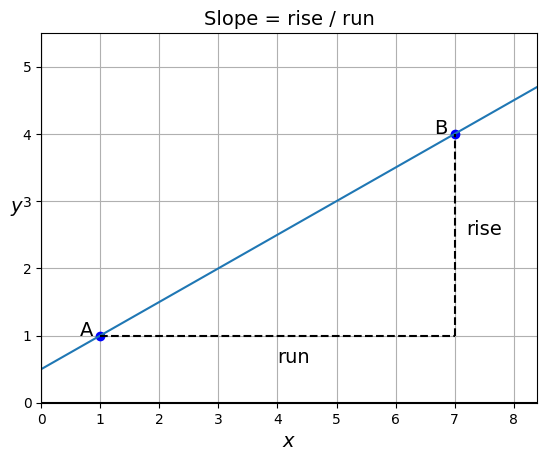

In [2]:
#@title
def get_AB_line(A_pos, B_pos, x_min=-1000, x_max=+1000):
    rise = B_pos[1] - A_pos[1]
    run = B_pos[0] - A_pos[0]
    slope = rise / run
    offset = A_pos[1] - slope * A_pos[0]
    return [x_min, x_max], [x_min * slope + offset, x_max * slope + offset]

def plot_AB_line(A_pos, B_pos, A_name="A", B_name="B"):
    for point, name in ((A_pos, A_name), (B_pos, B_name)):
        plt.plot(point[0], point[1], "bo")
        plt.text(point[0] - 0.35, point[1], name, fontsize=14)
    xs, ys = get_AB_line(A_pos, B_pos)
    plt.plot(xs, ys)

def plot_rise_over_run(A_pos, B_pos):
    plt.plot([A_pos[0], B_pos[0]], [A_pos[1], A_pos[1]], "k--")
    plt.text((A_pos[0] + B_pos[0]) / 2, A_pos[1] - 0.4, "run", fontsize=14)
    plt.plot([B_pos[0], B_pos[0]], [A_pos[1], B_pos[1]], "k--")
    plt.text(B_pos[0] + 0.2, (A_pos[1] + B_pos[1]) / 2, "rise", fontsize=14)

def show(axis="equal", ax=None, title=None, xlabel="$x$", ylabel="$y$"):
    ax = ax or plt.gca()
    ax.axis(axis)
    ax.grid()
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14, rotation=0)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')

A_pos = np.array([1, 1])
B_pos = np.array([7, 4])
plot_AB_line(A_pos, B_pos)
plot_rise_over_run(A_pos, B_pos)
show([0, 8.4, 0, 5.5], title="Slope = rise / run")

Comme vous le savez probablement, la pente d'une ligne droite (non verticale) peut être calculée en prenant deux points $\mathrm{A}$ et $\mathrm{B}$ sur la ligne et en calculant la « montée sur course » :

$slope = \dfrac{rise}{run} = \dfrac{\Delta y}{\Delta x} = \dfrac{y_\mathrm{B} - y_\mathrm{A}}{x_\mathrm{B} - x_\mathrm{A}}$


Dans cet exemple, la montée est de 3 et la course est de 6, donc la pente est de 3/6 = 0,5.

# Définir la pente d'une courbe

Mais que se passe-t-il si vous voulez connaître la pente de quelque chose autre qu’une ligne droite ? Par exemple, considérons la courbe définie par $y = f(x) = x^2$ :

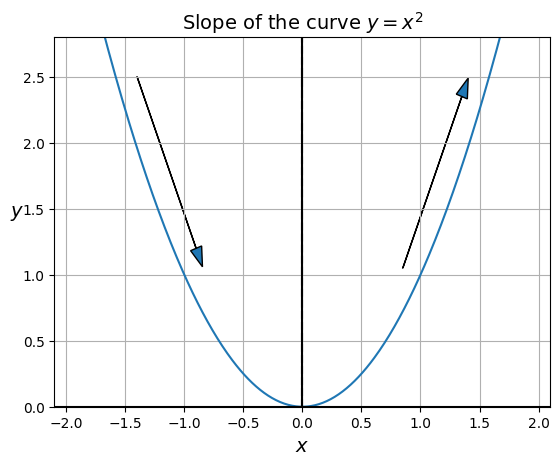

In [3]:
#@title
xs = np.linspace(-2.1, 2.1, 500)
ys = xs**2
plt.plot(xs, ys)

plt.plot([0, 0], [0, 3], "k--")
plt.arrow(-1.4, 2.5, 0.5, -1.3, head_width=0.1)
plt.arrow(0.85, 1.05, 0.5, 1.3, head_width=0.1)
show([-2.1, 2.1, 0, 2.8], title="Slope of the curve $y = x^2$")

Évidemment, la pente varie : à gauche (c'est-à-dire quand $x<0$), la pente est négative (c'est-à-dire quand on se déplace de gauche à droite, la courbe descend), tandis qu'à droite (c'est-à-dire quand $x>0$) la pente est positive (c'est-à-dire quand on se déplace de gauche à droite, la courbe monte). Au point $x=0$, la pente est égale à 0 (c'est-à-dire que la courbe est localement plate). Le fait que la pente soit nulle lorsque l’on atteint un minimum (voire un maximum) est d’une importance cruciale, et nous y reviendrons plus tard.

Comment chiffrer ces intuitions ? Eh bien, disons que nous voulons estimer la pente de la courbe en un point $\mathrm{A}$. Nous pouvons le faire en prenant un autre point $\mathrm{B}$ sur la courbe, pas trop loin, puis en calculant la pente entre ces deux points :

In [ ]:
#@title
def animate_AB_line(f, fp, f_str, x_A, axis=None):
    y_A = f(x_A)
    eps = 1e-4
    x_B_range = 1.5
    x_B = x_A + eps

    n_frames = 200
    text_offset_A = -0.2
    text_offset_B = +0.1
    x_min, x_max = -1000, 1000

    fig, ax = plt.subplots()

    # plot f(x)
    xs = np.linspace(-2.1, 2.1, 500)
    ys = f(xs)
    ax.plot(xs, ys)

    # plot the tangent to the curve at point A
    if fp:
        slope = fp(x_A)
        offset = y_A - slope * x_A
        ax.plot([x_min, x_max], [slope*x_min + offset, slope*x_max + offset],
                "y--")

    # plot the line AB and the labels A and B so they can be animated
    y_A = f(x_A)
    y_B = f(x_B)
    xs, ys = get_AB_line([x_A, y_A], [x_B, y_B])
    line_inf, = ax.plot(xs, ys, "-")
    line_AB, = ax.plot([x_A, x_B], [y_A, y_B], "bo-")
    ax.text(x_A + text_offset_A, y_A, "A", fontsize=14)
    B_text = ax.text(x_B + text_offset_B, y_B, "B", fontsize=14)

    # plot the grid and axis labels
    title = r"Slope of the curve $y = {}$ at $x_\mathrm{{A}} = {}$".format(f_str, x_A)
    show(axis or [-2.1, 2.1, 0, 2.8], title=title)

    def update_graph(i):
        x_B = x_A + x_B_range * np.cos(i * 2 * np.pi / n_frames) ** 3
        if np.abs(x_B - x_A) < eps:
            x_B = x_A + eps # to avoid division by 0
        y_B = f(x_B)
        xs, ys = get_AB_line([x_A, y_A], [x_B, y_B])
        line_inf.set_data(xs, ys)
        line_AB.set_data([x_A, x_B], [y_A, y_B])
        B_text.set_position([x_B + text_offset_B, y_B])
        return line_inf, line_AB

    anim = animation.FuncAnimation(fig, update_graph,
                                  init_func=lambda: update_graph(0),
                                  frames=n_frames,
                                  interval=20,
                                  blit=True)
    plt.close()
    return anim

animate_AB_line(lambda x: x**2, lambda x: 2*x, "x^2", -1)

Comme vous pouvez le constater, lorsque le point $\mathrm{B}$ est très proche du point $\mathrm{A}$, la ligne $(\mathrm{AB})$ devient presque impossible à distinguer de la courbe elle-même (au moins localement autour du point $\mathrm{A}$). La ligne $(\mathrm{AB})$ se rapproche de plus en plus de la ligne **tangente** à la courbe au point $\mathrm{A}$ : c'est la meilleure approximation linéaire de la courbe au point $\mathrm{A}$.

Il est donc logique de définir la pente de la courbe au point $\mathrm{A}$ comme la pente que la ligne $\mathrm{(AB)}$ approche lorsque $\mathrm{B}$ se rapproche infiniment de $\mathrm{A}$. Cette pente est appelée la **dérivée** de la fonction $f$ en $x=x_\mathrm{A}$. Par exemple, la dérivée de la fonction $f(x)=x^2$ en $x=x_\mathrm{A}$ est égale à $2x_\mathrm{A}$ (nous verrons comment obtenir ce résultat prochainement), donc sur le graphique ci-dessus, puisque le point $\mathrm{A}$ est situé à $x_\mathrm{A}=-1$, la tangente à la courbe en ce point a une pente de $-2$.

# Différenciabilité

Notez que certaines fonctions ne se comportent pas aussi bien que $x^2$. Par exemple, considérons la fonction $f(x)=|x|$, la valeur absolue de $x$ :

In [ ]:
#@title
animate_AB_line(lambda x: np.abs(x), None, "|x|", 0)

Peu importe combien vous zoomez sur l'origine (le point à $x=0, y=0$), la courbe ressemblera toujours à un V. La pente est de -1 pour tout $x < 0$, et elle est de +1 pour tout $x > 0$, mais **à $x = 0$, la pente n'est pas définie**, car il n'est pas possible de se rapprocher de la courbe. $y=|x|$ localement autour de l'origine à l'aide d'une ligne droite, quel que soit le zoom effectué sur ce point.

La fonction $f(x)=|x|$ est dite **non différentiable** en $x=0$ : sa dérivée est indéfinie en $x=0$. Cela signifie que la courbe $y=|x|$ a une pente indéfinie en ce point. Cependant, la fonction $f(x)=|x|$ est **différentiable** en tous les autres points.

Pour qu'une fonction $f(x)$ soit différentiable à un moment donné $x_\mathrm{A}$, la pente de la ligne $(\mathrm{AB})$ doit s'approcher d'une seule valeur finie car $\mathrm{B}$ se rapproche infiniment de $\mathrm{A}$.

Cela implique plusieurs contraintes :

* Tout d'abord, la fonction doit bien sûr être **définie** à $x_\mathrm{A}$. À titre de contre-exemple, la fonction $f(x)=\dfrac{1}{x}$ n'est pas définie en $x_\mathrm{A}=0$, elle n'est donc pas différentiable à ce stade.
* La fonction doit également être **continue** à $x_\mathrm{A}$, ce qui signifie que comme $x_\mathrm{B}$ se rapproche infiniment de $x_\mathrm{A}$, $f(x_\mathrm{B})$ doit également se rapprocher infiniment de $f(x_\mathrm{A})$. A titre de contre-exemple, $f(x)=\begin{cases}-1 \text{ if }x < 0\\+1 \text{ if }x \geq 0\end{cases}$ n'est pas continu en $x_\mathrm{A}=0$, même s'il est défini à ce point : en effet, lorsqu'on l'approche par le côté négatif, il ne se rapproche pas infiniment près de $f(0)=+1$. Par conséquent, il n’est pas continu à ce stade, et donc non plus différentiable.
* La fonction ne doit pas avoir de **point de rupture** à $x_\mathrm{A}$, ce qui signifie que la pente vers laquelle la ligne $(\mathrm{AB})$ s'approche lorsque $\mathrm{B}$ s'approche de $\mathrm{A}$ doit être la même, que $\mathrm{B}$ s'approche du côté gauche ou du côté droit. On a déjà vu un contre-exemple avec $f(x)=|x|$, qui est à la fois défini et continu en $x_\mathrm{A}=0$, mais qui a un point de rupture en $x_\mathrm{A}=0$ : la pente de la courbe $y=|x|$ est -1 à gauche, et +1 à droite.
* La courbe $y=f(x)$ ne doit pas être **verticale** au point $\mathrm{A}$. Un contre-exemple est $f(x)=\sqrt[3]{x}$, la racine cubique de $x$ : la courbe est verticale à l'origine, donc la fonction n'est pas dérivable en $x_\mathrm{A}=0$, comme vous pouvez le voir dans l'animation suivante :

In [ ]:
#@title
animate_AB_line(lambda x: np.cbrt(x), None, r"\sqrt[3]{x}", 0,
                axis=[-2.1, 2.1, -1.4, 1.4])

Voyons maintenant comment différencier réellement une fonction (c'est-à-dire trouver sa dérivée).

# Différencier une fonction

La discussion précédente conduit à la définition suivante :

<hr />

La **dérivée** d'une fonction $f(x)$ à $x = x_\mathrm{A}$ est notée $f'(x_\mathrm{A})$, et elle est définie comme :

$f'(x_\mathrm{A}) = \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim\dfrac{f(x_\mathrm{B}) - f(x_\mathrm{A})}{x_\mathrm{B} - x_\mathrm{A}}$

<hr />

N'ayez pas peur, c'est plus simple qu'il n'y paraît ! Vous reconnaîtrez peut-être l'équation _rise over run_ $\dfrac{y_\mathrm{B} - y_\mathrm{A}}{x_\mathrm{B} - x_\mathrm{A}}$ dont nous avons discuté plus tôt. C'est juste la pente de la ligne $\mathrm{(AB)}$. Et la notation $\underset{x_\mathrm{B} \to x_\mathrm{A}}\lim$ signifie que nous faisons en sorte que $x_\mathrm{B}$ se rapproche infiniment de $x_\mathrm{A}$. Donc, en clair, $f'(x_\mathrm{A})$ est la valeur à laquelle la pente de la ligne $\mathrm{(AB)}$ se rapproche lorsque $\mathrm{B}$ se rapproche infiniment de $\mathrm{A}$. C’est juste une manière formelle de dire exactement la même chose que précédemment.

## Exemple : trouver la dérivée de $x^2$

Regardons un exemple concret. Voyons si nous pouvons déterminer quelle est la pente de la courbe $y=x^2$, à tout moment $\mathrm{A}$ (essayez de comprendre chaque ligne, je vous promets que ce n'est pas si difficile) :

$
\begin{aligner*}
f'(x_\mathrm{A}) \, & = \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim\dfrac{f(x_\mathrm{B}) - f(x_\mathrm{A})}{x_\mathrm{B} - x_\mathrm{A}} \\
& = \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim\dfrac{{x_\mathrm{B}}^2 - {x_\mathrm{A}}^2}{x_\mathrm{B} - x_\mathrm{A}} \quad && \text{since } f(x) = x^2\\
& = \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim\dfrac{(x_\mathrm{B} - x_\mathrm{A})(x_\mathrm{B} + x_\mathrm{A})}{x_\mathrm{B} - x_\mathrm{A}}\quad && \text{since } {x_\mathrm{A}}^2 - {x_\mathrm{B}}^2 = (x_\mathrm{A}-x_\mathrm{B})(x_\mathrm{A}+x_\mathrm{B})\\
& = \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim(x_\mathrm{B} + x_\mathrm{A})\quad && \text{puisque les deux } (x_\mathrm{B} - x_\mathrm{A}) \text{ annuler}\\
& = \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim x_\mathrm{B} \, + \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim x_\mathrm{A}\quad && \text{puisque la limite d'une somme est la somme des limites}\\
& = x_\mathrm{A} \, + \underset{x_\mathrm{B} \to x_\mathrm{A}}\lim x_\mathrm{A} \quad && \text{depuis } x_\mathrm{B}\text{ approches } x_\mathrm{A} \\
& = x_\mathrm{A} + x_\mathrm{A} \quad && \text{since } x_\mathrm{A} \text{ reste constant lorsque } x_\mathrm{B}\text{ s'approche de } x_\mathrm{A} \\
& = 2x_\mathrm{A} &&
\fin{aligner*}
$

C'est tout ! Nous venons de prouver que la pente de $y = x^2$ en tout point $\mathrm{A}$ est $f'(x_\mathrm{A}) = 2x_\mathrm{A}$. Ce que nous avons fait s'appelle **différenciation** : trouver la dérivée d'une fonction.

Notez que nous avons utilisé quelques propriétés importantes des limites. Voici les principales propriétés que vous devez connaître pour travailler avec des dérivés :

* $\underset{x \to k}\lim c = c \quad$ si $c$ est une valeur constante qui ne dépend pas de $x$, alors la limite est simplement $c$.
* $\underset{x \to k}\lim x = k \quad$ si $x$ s'approche d'une certaine valeur $k$, alors la limite est $k$.
* $\underset{x \to k}\lim\,\left[f(x) + g(x)\right] = \underset{x \to k}\lim f(x) + \underset{x \to k}\lim g(x) \quad$ la limite d'une somme est la somme des limites
* $\underset{x \to k}\lim\,\left[f(x) \times g(x)\right] = \underset{x \to k}\lim f(x) \times \underset{x \to k}\lim g(x) \quad$ la limite d'un produit est le produit des limites

**Remarque importante :** dans le Deep Learning, la différenciation est presque toujours effectuée automatiquement par le framework que vous utilisez (comme TensorFlow ou PyTorch). C'est ce qu'on appelle la comparaison automatique, et j'ai fait [another notebook](https://github.com/ageron/handson-ml3/blob/main/extra_autodiff.ipynb) sur ce sujet. Cependant, vous devez quand même vous assurer de bien comprendre les dérivées, sinon elles viendront vous mordre un jour, par exemple lorsque vous utilisez une racine carrée dans votre fonction de coût sans vous rendre compte que sa dérivée tend vers l'infini lorsque $x$ tend vers 0 (astuce : vous devriez plutôt utiliser $\sqrt{x+\epsilon}$, où $\epsilon$ est une petite constante, comme $10^{-4}$).

Vous trouverez souvent une définition légèrement différente (mais équivalente) de la dérivée. Dérivons-le de la définition précédente. Tout d’abord, définissons $\epsilon = x_\mathrm{B} - x_\mathrm{A}$. Notez ensuite que $\epsilon$ approchera 0 à mesure que $x_\mathrm{B}$ approchera $x_\mathrm{A}$. Enfin, notez que $x_\mathrm{B} = x_\mathrm{A} + \epsilon$. Avec cela, nous pouvons reformuler la définition ci-dessus comme ceci :

$f'(x_\mathrm{A}) = \underset{\epsilon \to 0}\lim\dfrac{f(x_\mathrm{A} + \epsilon) - f(x_\mathrm{A})}{\epsilon}$

Pendant que nous y sommes, renommez simplement $x_\mathrm{A}$ en $x$, pour supprimer l'indice A ennuyeux et rendre l'équation plus simple à lire :

<hr />

$f'(x) = \underset{\epsilon \to 0}\lim\dfrac{f(x + \epsilon) - f(x)}{\epsilon}$

<hr />

D'accord! Utilisons maintenant cette nouvelle définition pour trouver la dérivée de $f(x) = x^2$ à tout moment $x$, et (espérons-le) nous devrions trouver le même résultat que ci-dessus (sauf en utilisant $x$ au lieu de $x_\mathrm{A}$) :

$
\begin{aligner*}
f'(x) \, & = \underset{\epsilon \to 0}\lim\dfrac{f(x + \epsilon) - f(x)}{\epsilon} \\
& = \underset{\epsilon \to 0}\lim\dfrac{(x + \epsilon)^2 - {x}^2}{\epsilon} \quad && \text{since } f(x) = x^2\\
& = \underset{\epsilon \to 0}\lim\dfrac{{x}^2 + 2x\epsilon + \epsilon^2 - {x}^2}{\epsilon}\quad && \text{since } (x + \epsilon)^2 = {x}^2 + 2x\epsilon + \epsilon^2\\
& = \underset{\epsilon \to 0}\lim\dfrac{2x\epsilon + \epsilon^2}{\epsilon}\quad && \text{puisque les deux } {x}^2 \text{ annuler}\\
& = \underset{\epsilon \to 0}\lim \, (2x + \epsilon)\quad && \text{puisque } 2x\epsilon \text{ et } \epsilon^2 \text{ peuvent tous deux être divisés par } \epsilon\\
& = 2x &&
\fin{aligner*}
$

Ouais ! Ça marche.

## Notations

Un mot sur les notations : il existe plusieurs autres notations pour la dérivée que vous trouverez dans la littérature :

$f'(x) = \dfrac{\mathrm{d}f(x)}{\mathrm{d}x} = \dfrac{\mathrm{d}}{\mathrm{d}x}f(x)$

Cette notation est également pratique lorsqu'une fonction n'est pas nommée. Par exemple, $\dfrac{\mathrm{d}}{\mathrm{d}x}[x^2]$ fait référence à la dérivée de la fonction $x \mapsto x^2$.

De plus, lorsque les gens parlent de la fonction $f(x)$, ils oublient parfois "$(x)$", et parlent simplement de la fonction $f$. Lorsque c’est le cas, la notation de la dérivée est également plus simple :

$f' = \dfrac{\mathrm{d}f}{\mathrm{d}x} = \dfrac{\mathrm{d}}{\mathrm{d}x}f$

La notation $f'$ est la notation de Lagrange, tandis que $\dfrac{\mathrm{d}f}{\mathrm{d}x}$ est la notation de Leibniz.

Il existe d'autres notations moins courantes, telles que la notation de Newton $\dot y$ (en supposant $y = f(x)$) ou la notation d'Euler $\mathrm{D}f$.

## Tracer la tangente à une courbe

Utilisons l'équation $f'(x) = 2x$ pour tracer la tangente à la courbe $y=x^2$ à différentes valeurs de $x$ (vous pouvez cliquer sur le bouton de lecture sous les graphiques pour lire l'animation) :

In [ ]:
#@title
def animate_tangent(f, fp, f_str):
    n_frames = 200
    x_min, x_max = -1000, 1000

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8), sharex=True)

    # plot f
    xs = np.linspace(-2.1, 2.1, 500)
    ys = f(xs)
    ax1.plot(xs, ys)

    # plot tangent
    line_tangent, = ax1.plot([x_min, x_max], [0, 0])

    # plot f'
    xs = np.linspace(-2.1, 2.1, 500)
    ys = fp(xs)
    ax2.plot(xs, ys, "r-")

    # plot points A
    point_A1, = ax1.plot(0, 0, "bo")
    point_A2, = ax2.plot(0, 0, "bo")

    show([-2.1, 2.1, 0, 2.8], ax=ax1, ylabel="$f(x)$",
        title=r"$y=f(x)=" + f_str + "$ and the tangent at $x=x_\mathrm{A}$")
    show([-2.1, 2.1, -4.2, 4.2], ax=ax2, ylabel="$f'(x)$",
        title=r"y=f'(x) and the slope of the tangent at $x=x_\mathrm{A}$")

    def update_graph(i):
        x = 1.5 * np.sin(2 * np.pi * i / n_frames)
        f_x = f(x)
        df_dx = fp(x)
        offset = f_x - df_dx * x
        line_tangent.set_data([x_min, x_max],
                              [df_dx * x_min + offset, df_dx * x_max + offset])
        point_A1.set_data(x, f_x)
        point_A2.set_data(x, df_dx)
        return line_tangent, point_A1, point_A2

    anim = animation.FuncAnimation(fig, update_graph,
                                  init_func=lambda: update_graph(0),
                                  frames=n_frames,
                                  interval=20,
                                  blit=True)
    plt.close()
    return anim

def f(x):
  return x**2

def fp(x):
  return 2*x

animate_tangent(f, fp, "x^2")

<hr />

**Remarque :** considérez la ligne tangente à la courbe $y=f(x)$ à un moment donné $\mathrm{A}$. Quelle est son équation ? Eh bien, puisque la tangente est une ligne droite, son équation doit ressembler à :

$y = \alpha x + \beta$

où $\alpha$ est la pente de la ligne et $\beta$ est le décalage (c'est-à-dire la coordonnée $y$ du point auquel la ligne croise l'axe vertical). Nous savons déjà que la pente de la tangente au point $\mathrm{A}$ est la dérivée de $f(x)$ en ce point, donc :

$\alpha = f'(x_\mathrm{A})$

Mais qu'en est-il du décalage $\beta$ ? Eh bien, nous savons aussi que la ligne tangente touche la courbe au point $\mathrm{A}$, nous savons donc que $\alpha x_\mathrm{A} + \beta = f(x_\mathrm{A})$. Donc :

$\beta = f(x_\mathrm{A}) - f'(x_\mathrm{A})x_\mathrm{A}$

On obtient donc l’équation suivante pour la tangente :

$y = f(x_\mathrm{A}) + f'(x_\mathrm{A})(x - x_\mathrm{A})$

Par exemple, la tangente à la courbe $y=x^2$ est donnée par :

$y = {x_\mathrm{A}}^2 + 2x_\mathrm{A}(x - x_\mathrm{A}) = 2x_\mathrm{A}x - x_\mathrm{A}^2$
<hr />

# Règles de différenciation

Une règle très importante est que **la dérivée d'une somme est la somme des dérivées**. Plus précisément, si l'on définit $f(x) = g(x) + h(x)$, alors $f'(x) = g'(x) + h'(x)$. C'est assez simple à prouver :

$
\begin{aligner*}
f'(x) & = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon) - f(x)}{\epsilon} && \quad\text{par définition}\\
& = \underset{\epsilon \to 0}\lim\dfrac{g(x+\epsilon) + h(x+\epsilon) - g(x) - h(x)}{\epsilon} && \quad \text{using }f(x) = g(x) + h(x) \\
& = \underset{\epsilon \to 0}\lim\dfrac{g(x+\epsilon) - g(x) + h(x+\epsilon) - h(x)}{\epsilon} && \quad \text{juste déplacer les termes}\\
& = \underset{\epsilon \to 0}\lim\dfrac{g(x+\epsilon) - g(x)}{\epsilon} + \underset{\epsilon \to 0}\lim\dfrac{h(x+\epsilon) - h(x)}{\epsilon} && \quad \text{puisque la limite d'une somme est la somme des limites}\\
& = g'(x) + h'(x) && \quad \text{en utilisant les définitions de }g'(x) \text{ et } h'(x)
\fin{aligner*}
$

De même, il est possible d'afficher les règles importantes suivantes (j'ai inclus les preuves à la fin de ce cahier, au cas où vous seriez curieux) :

|                  | Fonction $f$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; | Dérivé $f'$ &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; &nbsp; |
| ---------------- |---------------------------------- | ------------------------------- |
| **Constante** | $f(x) = c$ | $f'(x) = 0$ |
| **Somme** | $f(x) = g(x) + h(x)$ | $f'(x) = g'(x) + h'(x)$ |
| **Produit** | $f(x) = g(x) h(x)$ | $f'(x) = g(x)h'(x) + g'(x)h(x)$ |
| **Quotient** | $f(x) = \dfrac{g(x)}{h(x)}$ | $f'(x) = \dfrac{g'(x)h(x) - g(x)h'(x)}{h^2(x)}$ |
| **Puissance** | $f(x) = x^r$ avec $r \neq 0$ | $f'(x) = rx^{r-1}$ |
| **Exponentiel** | $f(x) = \exp(x)$ | $f'(x)=\exp(x)$ |
| **Logarithme** | $f(x) = \ln(x)$ | $f'(x) = \dfrac{1}{x} $ |
| **Péché** | $f(x) = \sin(x)$ | $f'(x) = \cos(x) $ |
| **Parce que** | $f(x) = \cos(x)$ | $f'(x) = -\sin(x) $ |
| **Bronzage** | $f(x) = \tan(x)$ | $f'(x) = \dfrac{1}{\cos^2(x)}$ |
| **Règle de chaîne** | $f(x) = g(h(x))$ | $f'(x) = g'(h(x))\,h'(x)$ |

---

Essayons de différencier une fonction simple en utilisant les règles ci-dessus : nous trouverons la dérivée de $f(x)=x^3+\cos(x)$. En utilisant la règle de dérivée des sommes, nous trouvons que $f'(x)=\dfrac{\mathrm{d}}{\mathrm{d}x}[x^3] + \dfrac{\mathrm{d}}{\mathrm{d}x}[\cos(x)]$. En utilisant la règle de la dérivée des puissances et de la fonction $\cos$, nous trouvons que $f'(x) = 3x^2 - \sin(x)$.

---

Essayons un exemple plus difficile : trouvons la dérivée de $f(x) = \sin(2 x^2) + 1$. Tout d’abord, définissons $u(x)=\sin(x) + 1$ et $v(x) = 2x^2$. En utilisant la règle des sommes, nous trouvons que $u'(x)=\dfrac{\mathrm{d}}{\mathrm{d}x}[sin(x)] + \dfrac{\mathrm{d}}{\mathrm{d}x}[1]$. Puisque la dérivée de la fonction $\sin$ est $\cos$ et que la dérivée des constantes est 0, nous constatons que $u'(x)=\cos(x)$. Ensuite, en utilisant la règle du produit, nous trouvons que $v'(x)=2\dfrac{\mathrm{d}}{\mathrm{d}x}[x^2] + \dfrac{\mathrm{d}}{\mathrm{d}x}[2]\,x^2$. Puisque la dérivée d’une constante est 0, le deuxième terme s’annule. Et puisque la règle de puissance nous dit que la dérivée de $x^2$ est $2x$, nous trouvons que $v'(x)=4x$. Enfin, en utilisant la règle de chaîne, puisque $f(x)=u(v(x))$, on trouve que $f'(x)=u'(v(x))\,v'(x)=\cos(2x^2)\,4x$.

Traçons $f$ suivi de $f'$, et utilisons $f'(x_\mathbf{A})$ pour trouver la pente de la tangente à un moment donné $\mathbf{A}$ :

In [ ]:
#@title
animate_tangent(lambda x: np.sin(2*x**2) + 1, lambda x: 4*x*np.cos(2*x**2), r"\sin(2x^2)+1")

## La règle de la chaîne

La règle de la chaîne est plus facile à retenir en utilisant la notation de Leibniz :

Si $f(x)=g(h(x))$ et $y=h(x)$, alors : $\dfrac{\mathrm{d}f}{\mathrm{d}x} = \dfrac{\mathrm{d}f}{\mathrm{d}y} \dfrac{\mathrm{d}y}{\mathrm{d}x}$

En effet, $\dfrac{\mathrm{d}f}{\mathrm{d}y} = f'(y) = f'(h(x))$ et $\dfrac{\mathrm{d}y}{\mathrm{d}x}=h'(x)$.

Il est possible d'enchaîner de nombreuses fonctions. Par exemple, si $f(x)=g(h(i(x)))$ et que nous définissons $y=i(x)$ et $z=h(y)$, alors $\dfrac{\mathrm{d}f}{\mathrm{d}x} = \dfrac{\mathrm{d}f}{\mathrm{d}z} \dfrac{\mathrm{d}z}{\mathrm{d}y} \dfrac{\mathrm{d}y}{\mathrm{d}x}$. En utilisant la notation de Lagrange, on obtient $f'(x)=g'(z)\,h'(y)\,i'(x)=g'(h(i(x)))\,h'(i(x))\,i'(x)$

La règle de la chaîne est cruciale dans le Deep Learning, car un réseau neuronal est essentiellement une longue composition de fonctions. Par exemple, un réseau de neurones denses à 3 couches correspond à la fonction suivante : $f(\mathbf{x})=\operatorname{Dense}_3(\operatorname{Dense}_2(\operatorname{Dense}_1(\mathbf{x})))$ (dans cet exemple, $\operatorname{Dense}_3$ est la couche de sortie).

# Dérivés et optimisation

Lorsque nous essayons d'optimiser une fonction $f(x)$, nous recherchons les valeurs de $x$ qui minimisent (ou maximisent) la fonction.

Il est important de noter que lorsqu'une fonction atteint un minimum ou un maximum, en supposant qu'elle soit différentiable à ce stade, la dérivée sera nécessairement égale à 0. Par exemple, vous pouvez vérifier l'animation ci-dessus et remarquer que chaque fois que la fonction $f$ (dans le graphique du haut) atteint un maximum ou un minimum, alors la dérivée $f'$ (dans le graphique du bas) est égale à 0.

Ainsi, une façon d’optimiser une fonction consiste à la différencier et à trouver analytiquement toutes les valeurs pour lesquelles la dérivée est 0, puis à déterminer laquelle de ces valeurs optimise la fonction (le cas échéant). Par exemple, considérons la fonction $f(x)=\dfrac{1}{4}x^4 - x^2 + \dfrac{1}{2}$. En utilisant les règles de dérivée (en particulier la règle de somme, la règle de produit, la règle de puissance et la règle de constante), nous trouvons que $f'(x)=x^3 - 2x$. On recherche les valeurs de $x$ pour lesquelles $f'(x)=0$, donc $x^3-2x=0$, et donc $x(x^2-2)=0$. Donc $x=0$, ou $x=\sqrt2$ ou $x=-\sqrt2$. Comme vous pouvez le voir sur le graphique suivant de $f(x)$, ces 3 valeurs correspondent à des extrema locaux. Deux minimums globaux $f\left(\sqrt2\right)=f\left(-\sqrt2\right)=-\dfrac{1}{2}$ et un maximum local $f(0)=\dfrac{1}{2}$.

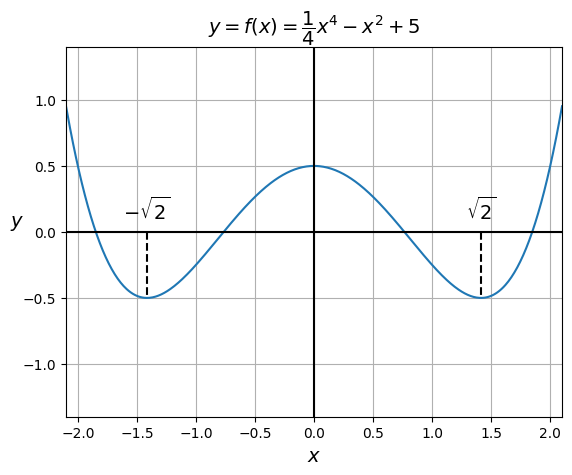

In [ ]:
#@title
def f(x):
  return 1/4 * x**4 - x**2 + 1/2

xs = np.linspace(-2.1, 2.1, 500)
ys = f(xs)
plt.plot(xs, ys)
plt.plot([np.sqrt(2), np.sqrt(2)], [0, f(np.sqrt(2))], "k--")
plt.plot([-np.sqrt(2), -np.sqrt(2)], [0, f(-np.sqrt(2))], "k--")
plt.text(-np.sqrt(2), 0.1, r"$-\sqrt{2}$",
         fontsize=14, horizontalalignment="center")
plt.text(np.sqrt(2), 0.1, r"$\sqrt{2}$",
         fontsize=14, horizontalalignment="center")
show(axis=[-2.1, 2.1, -1.4, 1.4], title=r"$y=f(x)=\dfrac{1}{4}x^4 - x^2 + 5$")

Si une fonction a un extremum local en un point $x_\mathrm{A}$ et est dérivable à ce point, alors $f'(x_\mathrm{A})=0$. Cependant, l’inverse n’est pas toujours vrai. Par exemple, considérons $f(x)=x^3$. Sa dérivée est $f'(x)=x^2$, qui est égale à 0 en $x_\mathrm{A}=0$. Pourtant, ce point n’est _pas_ un extremum, comme vous pouvez le voir sur le schéma suivant. C'est juste un seul point où la pente est de 0.

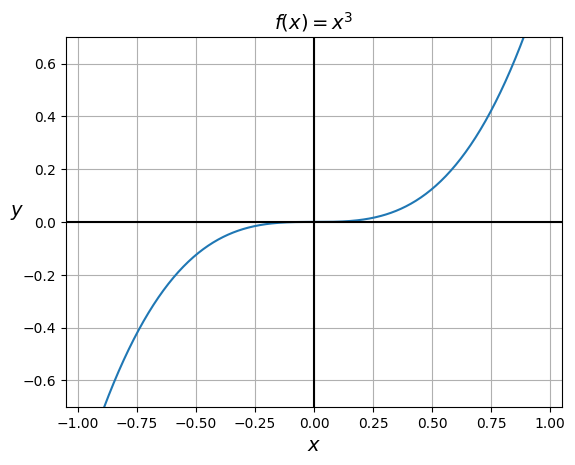

In [ ]:
#@title
def f(x):
  return x**3

xs = np.linspace(-1.05, 1.05, 500)
ys = f(xs)
plt.plot(xs, ys)
show(axis=[-1.05, 1.05, -0.7, 0.7], title=r"$f(x)=x^3$")

En bref, vous pouvez optimiser une fonction en déterminant analytiquement les points auxquels la dérivée est égale à 0, puis en étudiant uniquement ces points. C'est une solution magnifiquement élégante, mais elle demande beaucoup de travail et ce n'est pas toujours facile, ni même possible. Pour les réseaux de neurones, c'est pratiquement impossible.

Une autre option pour optimiser une fonction consiste à effectuer une **Descente de gradient** (nous envisagerons de minimiser la fonction, mais le processus serait presque identique si nous essayions de maximiser une fonction à la place) : commencez à un point aléatoire $x_0$, puis utilisez la dérivée de la fonction pour déterminer la pente à ce point, et déplacez-vous un peu vers le bas, puis répétez le processus jusqu'à ce que vous atteigniez un minimum local, et croisez les doigts dans l'espoir que ce soit le minimum global.

À chaque itération, la taille du pas est proportionnelle à la pente, de sorte que le processus ralentit naturellement à mesure qu'il s'approche d'un minimum local. Chaque étape est également proportionnelle au taux d'apprentissage : un paramètre de l'algorithme de descente de gradient lui-même (puisqu'il ne s'agit pas d'un paramètre de la fonction que nous optimisons, on l'appelle un **hyperparamètre**).

Voici une animation de ce processus pour la fonction $f(x)=\dfrac{1}{4}x^4 - x^2 + \dfrac{1}{2}$ :

In [ ]:
#@title
def animate_gradient_descent(f, fp, f_str, x_0):
    learning_rate = 0.01
    n_frames = 200
    x_min, x_max = -1000, 1000

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8), sharex=True)

    # plot f
    xs = np.linspace(-2.1, 2.1, 500)
    ys = f(xs)
    ax1.plot(xs, ys)

    # plot tangent
    line_tangent, = ax1.plot([x_min, x_max], [0, 0])

    # plot f'
    xs = np.linspace(-2.1, 2.1, 500)
    ys = fp(xs)
    ax2.plot(xs, ys, "r-")

    # plot points A
    point_A1, = ax1.plot(0, 0, "bo")
    point_A2, = ax2.plot(0, 0, "bo")

    show([-2.1, 2.1, -1.4, 1.4], ax=ax1, ylabel="$f(x)$",
        title=r"$y=f(x)=" + f_str + "$ and the tangent at $x=x_\mathrm{A}$")
    show([-2.1, 2.1, -4.2, 4.2], ax=ax2, ylabel="$f'(x)$",
        title=r"$y=f'(x)$ and the slope of the tangent at $x=x_\mathrm{A}$")

    xs = []
    x = x_0
    for index in range(n_frames):
      xs.append(x)
      slope = fp(x)
      x = x - slope * learning_rate

    def update_graph(i):
        x = xs[i]
        f_x = f(x)
        df_dx = fp(x)
        offset = f_x - df_dx * x
        line_tangent.set_data([x_min, x_max],
                              [df_dx * x_min + offset, df_dx * x_max + offset])
        point_A1.set_data(x, f_x)
        point_A2.set_data(x, df_dx)
        return line_tangent, point_A1, point_A2

    anim = animation.FuncAnimation(fig, update_graph,
                                  init_func=lambda: update_graph(0),
                                  frames=n_frames,
                                  interval=20,
                                  blit=True)
    plt.close()
    return anim

def f(x):
  return 1/4 * x**4 - x**2 + 1/2

def fp(x):
  return x**3 - 2*x

animate_gradient_descent(f, fp, r"\dfrac{1}{4}x^4 - x^2 + \dfrac{1}{2}",
                         x_0=1/4)

Dans cet exemple, nous avons commencé avec $x_0 = \dfrac{1}{4}$, donc la descente de gradient s'est « déroulée » vers la valeur minimale à $x = \sqrt2$. Mais si on avait commencé à $x_0 = -\dfrac{1}{4}$, cela serait allé vers $-\sqrt2$. Cela illustre le fait que la valeur initiale est importante : selon $x_0$, l'algorithme peut converger vers un minimum global (hourra !) ou vers un minimum local médiocre (bouh !) ou rester bloqué sur un plateau, comme un point d'inflexion horizontal (bouh !).

Il existe de nombreuses variantes de l'algorithme de descente de gradient, abordées au chapitre 11 du livre. Ce sont ceux qui nous intéressent en Deep Learning. Ils reposent tous sur la dérivée de la fonction de coût par rapport aux paramètres du modèle (nous discuterons des fonctions à paramètres multiples plus loin dans ce cahier).

# Dérivés d'ordre supérieur

Que se passe-t-il si l'on essaie de différencier la fonction $f'(x)$ ? Eh bien, nous obtenons ce qu'on appelle la dérivée du second ordre, notée $f''(x)$, ou $\dfrac{\mathrm{d}^2f}{\mathrm{d}x^2}$. Si nous répétons le processus en différenciant $f''(x)$, nous obtenons la dérivée du troisième ordre $f'''(x)$, ou $\dfrac{\mathrm{d}^3f}{\mathrm{d}x^3}$. Et nous pourrions continuer à obtenir des dérivés d’ordre supérieur.

Quelle est l’intuition derrière les dérivées du second ordre ? Eh bien, puisque la dérivée (de premier ordre) représente le taux de changement instantané de $f$ en chaque point, la dérivée de second ordre représente le taux de changement instantané du taux de changement lui-même, en d'autres termes, vous pouvez le considérer comme l'**accélération** de la courbe : si $f''(x) < 0$, alors la courbe accélère "vers le bas", si $f''(x) > 0$ alors la courbe accélère "vers le haut", et si $f''(x) = 0$, alors la courbe est localement une ligne droite. Notez qu'une courbe peut aller vers le haut (c'est-à-dire $f'(x)>0$) mais aussi accélérer vers le bas (c'est-à-dire $f''(x) < 0$) : par exemple, imaginez la trajectoire d'une pierre lancée vers le haut, car elle est ralentie par la gravité (qui accélère constamment la pierre vers le bas).

Le Deep Learning n’utilise généralement que des dérivées du premier ordre, mais vous rencontrerez parfois des algorithmes d’optimisation ou des fonctions de coût basés sur des dérivées du second ordre.

# Dérivées partielles

Jusqu'à présent, nous n'avons considéré que les fonctions avec une seule variable $x$. Que se passe-t-il lorsqu'il y a plusieurs variables ? Par exemple, commençons par une fonction simple à 2 variables : $f(x,y)=\sin(xy)$. Si nous traçons cette fonction en utilisant $z=f(x,y)$, nous obtenons le graphique 3D suivant. J'ai également tracé un point $\mathrm{A}$ sur la surface, ainsi que deux lignes que je décrirai sous peu.

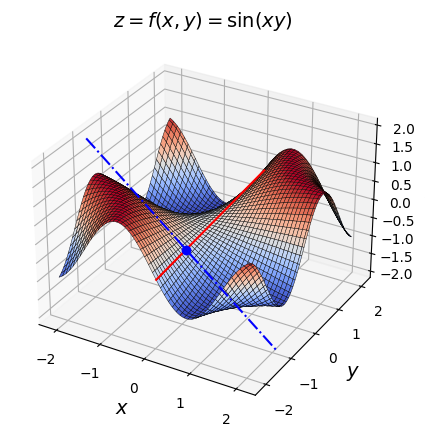

In [ ]:
#@title
def plot_3d(f, title):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    xs = np.linspace(-2.1, 2.1, 100)
    ys = np.linspace(-2.1, 2.1, 100)
    xs, ys = np.meshgrid(xs, ys)
    zs = f(xs, ys)

    surface = ax.plot_surface(xs, ys, zs,
                              cmap="coolwarm",
                              linewidth=0.3, edgecolor='k')

    ax.set_xlabel("$x$", fontsize=14)
    ax.set_ylabel("$y$", fontsize=14)
    ax.set_zlabel("$z$", fontsize=14)
    ax.set_title(title, fontsize=14)
    return ax

def plot_tangents(ax, x_A, y_A, f, df_dx, df_dy):
    ax.plot3D([x_A], [y_A], f(x_A, y_A), "bo", zorder=10)
    x_min, x_max = -2.1, 2.1
    slope_x = df_dx(x_A, y_A)
    offset_x = f(x_A, y_A) - slope_x * x_A
    ax.plot3D([x_min, x_max], [y_A, y_A],
              [slope_x * x_min + offset_x, slope_x * x_max + offset_x], "b-.",
              zorder=5)
    y_min, y_max = -2.1, 2.1
    slope_y = df_dy(x_A, y_A)
    offset_y = f(x_A, y_A) - slope_y * y_A
    ax.plot3D([x_A, x_A], [y_min, y_max],
              [slope_y * y_min + offset_y, slope_y * y_max + offset_y], "r-",
              zorder=5)

def f(x, y):
    return np.sin(x * y)

def df_dx(x, y):
    return y * np.cos(x * y)

def df_dy(x, y):
    return x * np.cos(x * y)

ax = plot_3d(f, r"$z = f(x, y) = \sin(xy)$")
plot_tangents(ax, 0.1, -1, f, df_dx, df_dy)

plt.show()

Si vous vous teniez sur cette surface au point $\mathrm{A}$ et marchiez le long de l'axe $x$ vers la droite (en augmentant $x$), votre chemin descendrait assez fortement (le long de la ligne bleue pointillée). La pente le long de cet axe serait négative. Cependant, si vous marchiez le long de l'axe $y$, vers l'arrière (en augmentant $y$), alors votre chemin serait presque plat (le long de la ligne rouge continue), au moins localement : la pente le long de cet axe, au point $\mathrm{A}$, serait très légèrement positive.

Comme vous pouvez le constater, un seul nombre ne suffit plus pour décrire la pente de la fonction en un point donné. Nous avons besoin d'une pente pour l'axe $x$ et d'une pente pour l'axe $y$. Une pente pour chaque variable. Pour trouver la pente le long de l'axe $x$, appelée **dérivée partielle de $f$ par rapport à $x$**, et notée $\dfrac{\partial f}{\partial x}$ (avec $\partial$ bouclé), on peut différencier $f(x,y)$ par rapport à $x$ tout en traitant toutes les autres variables (dans ce cas uniquement $y$) comme des constantes :

$ \dfrac{\partial f}{\partial x} = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon, y) - f(x,y)}{\epsilon}$

Si vous utilisez les règles dérivées répertoriées précédemment (dans cet exemple, vous aurez juste besoin de la règle produit et de la règle chaîne), en veillant à traiter $y$ comme une constante, alors vous trouverez :

$ \dfrac{\partial f}{\partial x} = y\cos(xy)$

De même, la dérivée partielle de $f$ par rapport à $y$ est définie comme :

$ \dfrac{\partial f}{\partial y} = \underset{\epsilon \to 0}\lim\dfrac{f(x, y+\epsilon) - f(x,y)}{\epsilon}$

Toutes les variables, à l'exception de $y$, sont traitées comme des constantes (juste $x$ dans cet exemple). En utilisant les règles de dérivée, on obtient :

$ \dfrac{\partial f}{\partial y} = x\cos(xy)$

Nous disposons maintenant d'équations pour calculer la pente le long de l'axe $x$ et le long de l'axe $y$. Mais qu’en est-il des autres directions ? Si vous vous trouviez à la surface au point $\mathrm{A}$, vous pourriez décider de marcher dans la direction de votre choix, pas seulement le long des axes $x$ ou $y$. Quelle serait alors la pente ? Ne devrions-nous pas calculer la pente dans toutes les directions possibles ?

Eh bien, on peut montrer que si toutes les dérivées partielles sont définies et continues dans un voisinage autour du point $\mathrm{A}$, alors la fonction $f$ est **totalement différentiable** à ce point, ce qui signifie qu'elle peut être localement approchée par un plan $P_\mathrm{A}$ (le plan tangent à la surface au point $\mathrm{A}$). Dans ce cas, avoir uniquement les dérivées partielles le long de chaque axe ($x$ et $y$ dans notre cas) suffit pour caractériser parfaitement ce plan. Son équation est :

$z = f(x_\mathrm{A},y_\mathrm{A}) + (x - x_\mathrm{A})\dfrac{\partial f}{\partial x}(x_\mathrm{A},y_\mathrm{A}) + (y - y_\mathrm{A})\dfrac{\partial f}{\partial y}(x_\mathrm{A},y_\mathrm{A})$

En Deep Learning, on aura généralement affaire à des fonctions bien comportées et totalement différentiables en tout point où toutes les dérivées partielles sont définies, mais il faut savoir que certaines fonctions ne sont pas très belles. Par exemple, considérons la fonction :

$h(x,y)=\begin{cases}0 \text { if } x=0 \text{ or } y=0\\1 \text { otherwise}\end{cases}$

A l'origine (c'est-à-dire à $(x,y)=(0,0)$), les dérivées partielles de la fonction $h$ par rapport à $x$ et $y$ sont toutes deux parfaitement définies : elles sont égales à 0. Pourtant la fonction ne peut clairement pas être approchée par un plan en ce point. Il n'est pas totalement dérivable à ce stade (mais il est totalement dérivable en tout point hors des axes).

# Dégradés

Jusqu'à présent, nous n'avons considéré que les fonctions avec une seule variable $x$, ou avec 2 variables, $x$ et $y$, mais le paragraphe précédent s'applique également aux fonctions avec plus de variables. Considérons donc une fonction $f$ avec des variables $n$ : $f(x_1, x_2, \dots, x_n)$. Pour plus de commodité, nous définirons un vecteur $\mathbf{x}$ dont les composantes sont ces variables :

$\mathbf{x}=\begin{pmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{pmatrix}$

Désormais, $f(\mathbf{x})$ est plus facile à écrire que $f(x_1, x_2, \dots, x_n)$.

Le gradient de la fonction $f(\mathbf{x})$ à un moment donné $\mathbf{x}_\mathrm{A}$ est le vecteur dont les composantes sont toutes les dérivées partielles de la fonction à ce point. Il est noté $\nabla f(\mathbf{x}_\mathrm{A})$, ou parfois $\nabla_{\mathbf{x}_\mathrm{A}}f$ :

$\nabla f(\mathbf{x}_\mathrm{A}) = \begin{pmatrix}
\dfrac{\partial f}{\partial x_1}(\mathbf{x}_\mathrm{A})\\
\dfrac{\partial f}{\partial x_2}(\mathbf{x}_\mathrm{A})\\
\vdots\\
\dfrac{\partial f}{\partial x_n}(\mathbf{x}_\mathrm{A})\\
\end{pmatrix}$

En supposant que la fonction est totalement différentiable au point $\mathbf{x}_\mathbf{A}$, alors la surface qu'elle décrit peut être approchée par un plan en ce point (comme discuté dans la section précédente), et le vecteur gradient est celui qui pointe vers la pente la plus raide sur ce plan.

## Descente de Dégradé, revisitée

En Deep Learning, l’algorithme de descente de gradient dont nous avons parlé plus tôt est basé sur des gradients plutôt que sur des dérivées (d’où son nom). Cela fonctionne à peu près de la même manière, mais en utilisant des vecteurs au lieu de scalaires : commencez simplement par un vecteur aléatoire $\mathbf{x}_0$, puis calculez le gradient de $f$ à ce point, et effectuez un petit pas dans la direction opposée, puis répétez jusqu'à convergence. Plus précisément, à chaque étape $t$, calculez $\mathbf{x}_t = \mathbf{x}_{t-1} - \eta \nabla f(\mathbf{x}_{t-1})$. La constante $\eta$ est le taux d'apprentissage, généralement une petite valeur telle que $10^{-3}$. En pratique, on utilise généralement des variantes plus efficaces de cet algorithme, mais l’idée générale reste la même.

En Deep Learning, la lettre $\mathbf{x}$ est généralement utilisée pour représenter les données d'entrée. Lorsque vous _utilisez_ un réseau neuronal pour faire des prédictions, vous alimentez le réseau neuronal avec les entrées $\mathbf{x}$ et vous récupérez une prédiction $\hat{y} = f(\mathbf{x})$. La fonction $f$ traite les paramètres du modèle comme des constantes. Nous pouvons utiliser une notation plus explicite en écrivant $\hat{y} = f_\mathbf{w}(\mathbf{x})$, où $\mathbf{w}$ représente les paramètres du modèle et indique que la fonction s'appuie sur eux, mais les traite comme des constantes.

Cependant, lors de l'entraînement d'un réseau de neurones, nous faisons tout le contraire : tous les exemples d'entraînement sont regroupés dans une matrice $\mathbf{X}$, toutes les étiquettes sont regroupées dans un vecteur $\mathbf{y}$, et $\mathbf{X}$ et $\mathbf{y}$ sont traités comme des constantes, tandis que $\mathbf{w}$ est traité comme variable : en particulier, nous essayons de minimiser la fonction de coût $\mathcal L_{\mathbf{X}, \mathbf{y}}(\mathbf{w}) = g(f_{\mathbf{X}}(\mathbf{w}), \mathbf{y})$, où $g$ est une fonction qui mesure "l'écart" entre les prédictions $f_{\mathbf{X}}(\mathbf{w})$ et les étiquettes $\mathbf{y}$, où $f_{\mathbf{X}}(\mathbf{w})$ représente le vecteur contenant les prédictions pour chaque exemple d'entraînement. La minimisation de la fonction de perte est généralement réalisée à l'aide de Gradient Descent (ou une variante de GD) : on commence avec des paramètres aléatoires du modèle $\mathbf{w}_0$, puis on calcule $\nabla \mathcal L(\mathbf{w}_0)$ et on utilise ce vecteur gradient pour effectuer une étape de Gradient Descent, puis on répète le processus jusqu'à convergence. Il est crucial de comprendre que le gradient de la fonction de perte concerne les paramètres du modèle $\mathbf{w}$ (_pas_ les entrées $\mathbf{x}$).

# Jacobiens

Jusqu’à présent, nous n’avons considéré que les fonctions qui génèrent un scalaire, mais il est possible de générer des vecteurs à la place. Par exemple, un réseau neuronal de classification génère généralement une probabilité pour chaque classe. Ainsi, s'il existe des classes $m$, le réseau neuronal génère un vecteur dimensionnel $d$ pour chaque entrée.

En Deep Learning, il suffit généralement de différencier la fonction de perte, qui génère presque toujours un seul nombre scalaire. Mais supposons une seconde que vous souhaitiez différencier une fonction $\mathbf{f}(\mathbf{x})$ qui génère des vecteurs dimensionnels $d$. La bonne nouvelle est que vous pouvez traiter chaque dimension _output_ indépendamment des autres. Cela vous donnera une dérivée partielle pour chaque dimension d'entrée et chaque dimension de sortie. Si vous les mettez tous dans une seule matrice, avec une colonne par dimension d'entrée et une ligne par dimension de sortie, vous obtenez ce que l'on appelle la **matrice jacobienne**.

$
\mathbf{J}_\mathbf{f}(\mathbf{x}_\mathbf{A}) = \begin{pmatrix}
\dfrac{\partial f_1}{\partial x_1}(\mathbf{x}_\mathbf{A})
&& \dfrac{\partial f_1}{\partial x_2}(\mathbf{x}_\mathbf{A})
&& \points
&& \dfrac{\partial f_1}{\partial x_n}(\mathbf{x}_\mathbf{A})\\
\dfrac{\partial f_2}{\partial x_1}(\mathbf{x}_\mathbf{A})
&& \dfrac{\partial f_2}{\partial x_2}(\mathbf{x}_\mathbf{A})
&& \points
&& \dfrac{\partial f_2}{\partial x_n}(\mathbf{x}_\mathbf{A})\\
\vdots && \vdots && \ddots && \vdots \\
\dfrac{\partial f_m}{\partial x_1}(\mathbf{x}_\mathbf{A})
&& \dfrac{\partial f_m}{\partial x_2}(\mathbf{x}_\mathbf{A})
&& \points
&& \dfrac{\partial f_m}{\partial x_n}(\mathbf{x}_\mathbf{A})
\fin{pmatrix}
$

Les dérivées partielles elles-mêmes sont souvent appelées les **Jacobiens**. Ce ne sont que les dérivées partielles du premier ordre de la fonction $\mathbf{f}$.

# Hessiens

Revenons à une fonction $f(\mathbf{x})$ qui prend un vecteur dimensionnel $n$ en entrée et sort un scalaire. Si vous déterminez l'équation de la dérivée partielle de $f$ par rapport à $x_i$ (le composant $i^\text{th}$ de $\mathbf{x}$), vous obtiendrez une nouvelle fonction de $\mathbf{x}$ : $\dfrac{\partial f}{\partial x_i}$. Vous pouvez ensuite calculer la dérivée partielle de cette fonction par rapport à $x_j$ (le composant $j^\text{th}$ de $\mathbf{x}$). Le résultat est une dérivée partielle d'une dérivée partielle : autrement dit, il s'agit d'une **dérivée partielle du second ordre**, également appelée **Hessienne**. Il est noté $\mathbf{x}$ : $\dfrac{\partial^2 f}{\partial x_jx_i}$. Si $i\neq j$, on l'appelle une **dérivée partielle mixte du second ordre**.
Ou bien, si $j=i$, on note $\dfrac{\partial^2 f}{\partial {x_i}^2}$

Regardons un exemple : $f(x, y)=\sin(xy)$. Comme nous l'avons montré précédemment, les dérivées partielles du premier ordre de $f$ sont : $\dfrac{\partial f}{\partial x}=y\cos(xy)$ et $\dfrac{\partial f}{\partial y}=x\cos(xy)$. Nous pouvons donc maintenant calculer tous les Hessiens (en utilisant les règles de dérivée dont nous avons parlé plus tôt) :

* $\dfrac{\partial^2 f}{\partial x^2} = \dfrac{\partial f}{\partial x}\left[y\cos(xy)\right] = -y^2\sin(xy)$
* $\dfrac{\partial^2 f}{\partial y\,\partial x} = \dfrac{\partial f}{\partial y}\left[y\cos(xy)\right] = \cos(xy) - xy\sin(xy)$
* $\dfrac{\partial^2 f}{\partial x\,\partial y} = \dfrac{\partial f}{\partial x}\left[x\cos(xy)\right] = \cos(xy) - xy\sin(xy)$
* $\dfrac{\partial^2 f}{\partial y^2} = \dfrac{\partial f}{\partial y}\left[x\cos(xy)\right] = -x^2\sin(xy)$

Notez que $\dfrac{\partial^2 f}{\partial x\,\partial y} = \dfrac{\partial^2 f}{\partial y\,\partial x}$. C'est le cas chaque fois que toutes les dérivées partielles sont définies et continues dans un voisinage autour du point de différenciation.

La matrice contenant tous les Hessiens est appelée la **matrice Hessienne** :

$
\mathbf{H}_f(\mathbf{x}_\mathbf{A}) = \begin{pmatrix}
\dfrac{\partial^2 f}{\partial {x_1}^2}(\mathbf{x}_\mathbf{A})
&& \dfrac{\partial^2 f}{\partial x_1\, \partial x_2}(\mathbf{x}_\mathbf{A})
&& \points
&& \dfrac{\partial^2 f}{\partial x_1\, \partial x_n}(\mathbf{x}_\mathbf{A})\\
\dfrac{\partial^2 f}{\partial x_2\,\partial x_1}(\mathbf{x}_\mathbf{A})
&& \dfrac{\partial^2 f}{\partial {x_2}^2}(\mathbf{x}_\mathbf{A})
&& \points
&& \dfrac{\partial^2 f}{\partial x_2\, \partial x_n}(\mathbf{x}_\mathbf{A})\\
\vdots && \vdots && \ddots && \vdots \\
\dfrac{\partial^2 f}{\partial x_n\,\partial x_1}(\mathbf{x}_\mathbf{A})
&& \dfrac{\partial^2 f}{\partial x_n\,\partial x_2}(\mathbf{x}_\mathbf{A})
&& \points
&& \dfrac{\partial^2 f}{\partial {x_n}^2}(\mathbf{x}_\mathbf{A})\\
\fin{pmatrix}
$

Il existe d'excellents algorithmes d'optimisation qui tirent parti des Hessiens, mais dans la pratique, le Deep Learning ne les utilise presque jamais. En effet, si une fonction possède des variables $n$, il existe des Hessiens $n^2$ : puisque les réseaux de neurones comportent généralement plusieurs millions de paramètres, le nombre de Hessiens dépasserait les milliers de milliards. Même si nous disposions de la quantité de RAM nécessaire, les calculs seraient d’une lenteur prohibitive.

## Quelques preuves

Terminons en prouvant toutes les règles dérivées que nous avons énumérées plus tôt. Vous n'avez pas besoin de passer par toutes ces preuves pour être un bon praticien du Deep Learning, mais cela peut vous aider à mieux comprendre les dérivés.

## Constante : $f(x)=c$

$
\begin{aligner*}
f'(x) & = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon) - f(x)}{\epsilon} && \quad\text{par définition}\\
& = \underset{\epsilon \to 0}\lim\dfrac{c - c}{\epsilon} && \quad \text{using }f(x) = c \\
& = \underset{\epsilon \to 0}\lim 0 && \quad \text{depuis }c - c = 0\\
& = 0 && \quad \text{puisque la limite d'une constante est cette constante}
\fin{aligner*}
$

## Règle produit : $f(x)=g(x)h(x)$

$
\begin{aligner*}
f'(x) & = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon) - f(x)}{\epsilon} && \quad\text{par définition}\\
& = \underset{\epsilon \to 0}\lim\dfrac{g(x+\epsilon)h(x+\epsilon) - g(x)h(x)}{\epsilon} && \quad \text{using }f(x) = g(x)h(x) \\
& = \underset{\epsilon \to 0}\lim\dfrac{g(x+\epsilon)h(x+\epsilon) - g(x)h(x+\epsilon) + g(x)h(x + \epsilon) - g(x)h(x)}{\epsilon} && \quad \text{soustraire et ajouter }g(x)h(x + \epsilon)\\
& = \underset{\epsilon \to 0}\lim\dfrac{g(x+\epsilon)h(x+\epsilon) - g(x)h(x+\epsilon)}{\epsilon} + \underset{\epsilon \to 0}\lim\dfrac{g(x)h(x + \epsilon) - g(x)h(x)}{\epsilon} && \quad \text{puisque la limite d'une somme est la somme des limites}\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{g(x+\epsilon) - g(x)}{\epsilon}h(x+\epsilon)\right]} \,+\, \underset{\epsilon \to 0}\lim{\left[g(x)\dfrac{h(x + \epsilon) - h(x)}{\epsilon}\right]} && \quad \text{factorisation }h(x+\epsilon) \text{ et } g(x)\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{g(x+\epsilon) - g(x)}{\epsilon}h(x+\epsilon)\right]} \,+\, g(x)\underset{\epsilon \to 0}\lim{\dfrac{h(x + \epsilon) - h(x)}{\epsilon}} && \quad \text{sortir } g(x) \text{ de la limite puisqu'il ne dépend pas de }\epsilon\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{g(x+\epsilon) - g(x)}{\epsilon}h(x+\epsilon)\right]} \,+\, g(x)h'(x) && \quad \text{en utilisant la définition de }h'(x)\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{g(x+\epsilon) - g(x)}{\epsilon}\right]}\underset{\epsilon \to 0}\lim{h(x+\epsilon)} + g(x)h'(x) && \quad \text{puisque la limite d'un produit est le produit des limites}\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{g(x+\epsilon) - g(x)}{\epsilon}\right]}h(x) + h(x)g'(x) && \quad \text{puisque } h(x) \text{ est continu}\\
& = g'(x)h(x) + g(x)h'(x) && \quad \text{en utilisant la définition de }g'(x)
\fin{aligner*}
$

Notez que si $g(x)=c$ (une constante), alors $g'(x)=0$, donc l'équation se simplifie comme suit :

$f'(x)=c \, h'(x)$

## Règle de chaîne : $f(x)=g(h(x))$

$
\begin{aligner*}
f'(x) & = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon) - f(x)}{\epsilon} && \quad\text{par définition}\\
& = \underset{\epsilon \to 0}\lim\dfrac{g(h(x+\epsilon)) - g(h(x))}{\epsilon} && \quad \text{using }f(x) = g(h(x))\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{h(x+\epsilon)-h(x)}{h(x+\epsilon)-h(x)}\,\dfrac{g(h(x+\epsilon)) - g(h(x))}{\epsilon}\right]} && \quad \text{multiplier et diviser par }h(x+\epsilon) - h(x)\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{h(x+\epsilon)-h(x)}{\epsilon}\,\dfrac{g(h(x+\epsilon)) - g(h(x))}{h(x+\epsilon)-h(x)}\right]} && \quad \text{échange des dénominateurs}\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{h(x+\epsilon)-h(x)}{\epsilon}\right]} \underset{\epsilon \to 0}\lim{\left[\dfrac{g(h(x+\epsilon)) - g(h(x))}{h(x+\epsilon)-h(x)}\right]} && \quad \text{la limite d'un produit est le produit des limites}\\
& = h'(x) \underset{\epsilon \to 0}\lim{\left[\dfrac{g(h(x+\epsilon)) - g(h(x))}{h(x+\epsilon)-h(x)}\right]} && \quad \text{en utilisant la définition de }h'(x)\\
& = h'(x) \underset{\epsilon \to 0}\lim{\left[\dfrac{g(u) - g(v)}{u-v}\right]} && \quad \text{using }u=h(x+\epsilon) \text{ et } v=h(x)\\
& = h'(x) \underset{u \to v}\lim{\left[\dfrac{g(u) - g(v)}{u-v}\right]} && \quad \text{ puisque } h \text{ est continu, donc } \underset{\epsilon \to 0}\lim{u}=v\\
& = h'(x)g'(v) && \quad \text{ en utilisant la définition de } g'(v)\\
& = h'(x)g'(h(x)) && \quad \text{ puisque } v = h(x)
\fin{aligner*}
$

## Exponentiel : $f(x)=\exp(x)=e^x$

Il existe plusieurs définitions équivalentes du nombre $e$. L'un d'eux indique que $e$ est le nombre positif unique pour lequel $\underset{\epsilon \to 0}\lim{\dfrac{e^\epsilon - 1}{\epsilon}}=1$. Nous l'utiliserons dans cette preuve :

$
\begin{aligner*}
f'(x) & = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon) - f(x)}{\epsilon} && \quad\text{par définition}\\
& = \underset{\epsilon \to 0}\lim\dfrac{e^{x+\epsilon} - e^x}{\epsilon} && \quad \text{using }f(x) = e^x\\
& = \underset{\epsilon \to 0}\lim\dfrac{e^x e^\epsilon - e^x}{\epsilon} && \quad \text{en utilisant le fait que } x^{a+b}=x^a x^b\\
& = \underset{\epsilon \to 0}\lim{\left[e^x\dfrac{e^\epsilon - 1}{\epsilon}\right]} && \quad \text{factorisation }e^x\\
& = \underset{\epsilon \to 0}\lim{e^x} \, \underset{\epsilon \to 0}\lim{\dfrac{e^\epsilon - 1}{\epsilon}} && \quad \text{la limite d'un produit est le produit des limites}\\
& = \underset{\epsilon \to 0}\lim{e^x} && \quad \text{since }\underset{\epsilon \to 0}\lim{\dfrac{e^\epsilon - 1}{\epsilon}}=1\\
& = e^x && \quad \text{puisque } e^x \text{ ne dépend pas de }\epsilon
\fin{aligner*}
$

## Logarithme : $f(x) = \ln(x)$

Une autre définition du nombre $e$ est :

$e = \underset{n \to \infty}\lim\left(1+\dfrac{1}{n}\right)^n$

En définissant $\epsilon = \dfrac{1}{n}$, nous pouvons réécrire la définition précédente comme suit :

$e = \underset{\epsilon \to 0}\lim\left(1+\epsilon\right)^{1/\epsilon}$

Cela vous sera utile dans une seconde :

$
\begin{aligner*}
f'(x) & = \underset{\epsilon \to 0}\lim\dfrac{f(x+\epsilon) - f(x)}{\epsilon} && \quad\text{par définition}\\
& = \underset{\epsilon \to 0}\lim\dfrac{\ln(x+\epsilon) - \ln(x)}{\epsilon} && \quad \text{using }f(x) = \ln(x)\\
& = \underset{\epsilon \to 0}\lim\dfrac{\ln\left(\dfrac{x+\epsilon}{x}\right)}{\epsilon} && \quad \text{since }\ln(a)-\ln(b)=\ln\left(\dfrac{a}{b}\right)\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{1}{\epsilon} \, \ln\left(1 + \dfrac{\epsilon}{x}\right)\right]} && \quad \text{juste déplacer les choses un peu}\\
& = \underset{\epsilon \to 0}\lim{\left[\dfrac{1}{xu} \, \ln\left(1 + u\right)\right]} && \quad \text{defining }u=\dfrac{\epsilon}{x} \text{ et donc } \epsilon=xu\\
& = \underset{u \to 0}\lim{\left[\dfrac{1}{xu} \, \ln\left(1 + u\right)\right]} && \quad \text{remplacer } \underset{\epsilon \to 0}\lim \text{ par } \underset{u \to 0}\lim \text{ puisque }\underset{\epsilon \to 0}\lim u=0\\
& = \underset{u \to 0}\lim{\left[\dfrac{1}{x} \, \ln\left((1 + u)^{1/u}\right)\right]} && \quad \text{since }a\ln(b)=\ln(b^a)\\
& = \dfrac{1}{x}\underset{u \to 0}\lim{\left[\ln\left((1 + u)^{1/u}\right)\right]} && \quad \text{prenant }\dfrac{1}{x} \text{ car il ne dépend pas de }\epsilon\\
& = \dfrac{1}{x}\ln\left(\underset{u \to 0}\lim{(1 + u)^{1/u}}\right) && \quad \text{prendre }\ln\text{ puisqu'il s'agit d'une fonction continue}\\
& = \dfrac{1}{x}\ln(e) && \quad \text{since }e=\underset{u \to 0}\lim{(1 + u)^{1/u}}\\
& = \dfrac{1}{x} && \quad \text{depuis }\ln(e)=1
\fin{aligner*}
$

## Règle de puissance : $f(x)=x^r$, avec $r \neq 0$

Définissons $g(x)=e^x$ et $h(x)=\ln(x^r)$. Depuis $a = e^{\ln(a)}$, on peut réécrire $f$ comme $f(x)=g(h(x))$, ce qui permet d'utiliser la règle de chaîne :

$f'(x) = h'(x)g'(h(x))$

On connaît la dérivée de l'exponentielle : $g'(x)=e^x$. On connaît aussi la dérivée du logarithme népérien : $\ln'(x)=\dfrac{1}{x}$ donc $h'(x)=\dfrac{r}{x}$. Par conséquent :

$f'(x) = \dfrac{r}{x} e^{\ln(x^r)}$

Depuis $e^{\ln(a)} = a$, cette équation se simplifie comme suit :

$f'(x) = \dfrac{r}{x} x^r$

Et enfin :

$f'(x) = rx^{r - 1}$

Notez que la règle de puissance fonctionne pour n'importe quel $r \neq 0$, y compris les nombres négatifs et les nombres réels. Par exemple :

* si $f(x) = \dfrac{1}{x} = x^{-1}$, alors $f'(x)=-x^{-2}=-\dfrac{1}{x^2}$.
* si $f(x) = \sqrt{x} = x^{1/2}$, alors $f'(x)=\dfrac{1}{2}x^{-1/2}=\dfrac{1}{2\sqrt{x}}$

## Inverse multiplicatif : $f(x)=\dfrac{1}{h(x)}$
Tout d’abord, définissons $g(x) = \dfrac{1}{x}$. Cela conduit à $f(x)=g(h(x))$.
Nous pouvons maintenant utiliser la règle de chaîne :

$f'(x) = h'(x)g'(h(x))$

Depuis $g(x)=x^{-1}$, nous pouvons utiliser la règle de puissance pour trouver $g'(x)=-\dfrac{1}{x^2}$

Finalement, nous obtenons :

$f'(x) = -\dfrac{h'(x)}{h^2(x)}$

## Règle du quotient : $f(x)=\dfrac{g(x)}{h(x)}$

Réécrivons $f(x)$ en produit : $f(x)=g(x)u(x)$ avec $u(x)=\dfrac{1}{h(x)}$

Nous pouvons maintenant utiliser la règle du produit pour obtenir :

$f(x) = g'(x)u(x) + g(x)u'(x)$

En remplaçant $u(x)$ par $\dfrac{1}{h(x)}$ et en utilisant le résultat de la section précédente pour remplacer $u'(x)$ par $\dfrac{-h'(x)}{h^2(x)}$, nous obtenons :

$f(x) = g'(x)\dfrac{1}{h(x)} + g(x)\dfrac{-h'(x)}{h^2(x)}$

Maintenant, nous multiplions et divisons le premier terme par $h(x)$ :

$f(x) = \dfrac{g'(x)h(x)}{h^2(x)} - \dfrac{g(x)h'(x)}{h^2(x)}$

Et enfin :

$f(x) = \dfrac{g'(x)h(x) - g(x)h'(x)}{h^2(x)}$

## Péché : $f(x)=\sin(x)$

Pour cette preuve, nous devrons d’abord prouver que $\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta}=1$. Une façon de procéder consiste à considérer le schéma suivant :

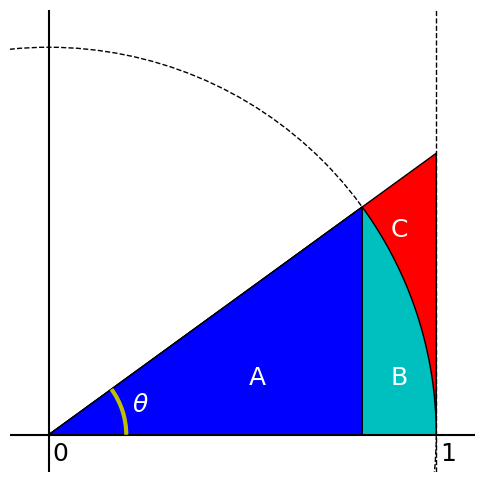

In [ ]:
#@title
angle = np.pi/5
A_pos = [np.cos(angle), np.sin(angle)]

fig, ax = plt.subplots(figsize=(6, 6))

from functools import partial
ax_text = partial(ax.text, color="w", fontsize=18, zorder=4,
                  horizontalalignment='center', verticalalignment='center')

circle = plt.Circle((0, 0), 1,
                    zorder=0, facecolor='w', edgecolor='k', linestyle="--")
triangle1 = plt.Polygon([[0, 0], [1, np.tan(angle)], [1, 0]],
                        zorder=1, facecolor='r', edgecolor='k')
arc_points = np.array([[0, 0]] + [[np.cos(a), np.sin(a)]
              for a in np.linspace(0, angle, 50)])
ax.fill(arc_points[:, 0], arc_points[:, 1],
        zorder=2, facecolor='c', edgecolor='k')
triangle2 = plt.Polygon([[0, 0], A_pos, [A_pos[0], 0]],
                        zorder=3, facecolor='b', edgecolor='k')
ax_text(2*np.cos(angle)/3, np.sin(angle)/4, "A")
ax_text((1+np.cos(angle))/2, np.sin(angle)/4, "B")
ax_text((1+np.cos(angle))/2, 0.9*np.sin(angle), "C")
ax_text(0.25*np.cos(angle/2), 0.25*np.sin(angle/2), r"$\theta$")
arc = mpl.patches.Arc([0, 0], 2*0.2, 2*0.2, theta1=0, theta2=angle*180/np.pi,
                      zorder=5, color='y', linewidth=3)
ax_text(0.03, -0.05, "0", color='k')
ax_text(1.03, -0.05, "1", color='k')

ax.axhline(y=0, color='k', zorder=4)
ax.axvline(x=0, color='k', zorder=4)
ax.axvline(x=1, color='k', zorder=4, linewidth=1, linestyle='--')
ax.axis('equal')
ax.axis([-0.1, 1.1, -0.1, 1.1])
ax.axis('off')
ax.add_artist(circle)
ax.add_artist(triangle1)
ax.add_artist(triangle2)
ax.add_patch(arc)
plt.show()

Le cercle est le cercle unité (rayon=1).

En supposant $0 < \theta < \dfrac{\pi}{2}$, l'aire du triangle bleu (aire $\mathrm{A}$) est égale à sa hauteur ($\sin(\theta)$) multipliée par sa base ($\cos(\theta)$) divisée par 2. Donc $\mathrm{A} = \dfrac{1}{2}\sin(\theta)\cos(\theta)$.

Le cercle unité a une aire de $\pi$, donc le secteur circulaire (en forme de tranche de pizza) a une aire de A + B = $\pi\dfrac{\theta}{2\pi} = \dfrac{\theta}{2}$.

Ensuite, le grand triangle (A + B + C) a une aire égale à sa hauteur ($\tan(\theta)$) multipliée par sa base (de longueur 1) divisée par 2, donc A + B + C = $\dfrac{\tan(\theta)}{2}$.

Lorsque $0 < \theta < \dfrac{\pi}{2}$, on a $\mathrm{A} < \mathrm{A} + \mathrm{B} < \mathrm{A} + \mathrm{B} + \mathrm{C}$, donc :

$\dfrac{1}{2}\sin(\theta)\cos(\theta) < \dfrac{\theta}{2} < \dfrac{\tan(\theta)}{2}$

On peut multiplier tous les termes par 2 pour supprimer les facteurs $\dfrac{1}{2}$. Nous pouvons également diviser par $\sin(\theta)$, qui est strictement positif (en supposant $0 < \theta < \dfrac{\pi}{2}$), donc les inégalités sont toujours valables :

$cos(\theta) < \dfrac{\theta}{\sin(\theta)} < \dfrac{\tan(\theta)}{\sin(\theta)}$

Rappelons que $\tan(\theta)=\dfrac{\sin(\theta)}{\cos(\theta)}$, donc le dernier terme se simplifie ainsi :

$cos(\theta) < \dfrac{\theta}{\sin(\theta)} < \dfrac{1}{\cos(\theta)}$

Puisque tous ces termes sont strictement positifs lorsque $0 < \theta < \dfrac{\pi}{2}$, on peut prendre leur inverse et changer le sens des inégalités :

<hr />

**Inégalités (1)**

$\dfrac{1}{cos(\theta)} > \dfrac{\sin(\theta)}{\theta} > \cos(\theta)$

en supposant que $0 < \theta < \dfrac{\pi}{2}$
<hr />

Maintenant, depuis $\sin(-\theta)=-\sin(\theta)$, nous voyons que $\dfrac{\sin(-\theta)}{-\theta}=\dfrac{\sin(\theta)}{\theta}$. De plus, $\cos(-\theta)=\cos(\theta)$, et donc $\dfrac{1}{\cos(-\theta)}=\dfrac{1}{\cos(\theta)}$. En remplaçant les termes dans les inégalités (1), on obtient :

$\dfrac{1}{cos(-\theta)} > \dfrac{\sin(-\theta)}{-\theta} > \cos(-\theta)$

en supposant que $0 < \theta < \dfrac{\pi}{2}$

Autrement dit, les inégalités (1) valent également pour $-\dfrac{\pi}{2} < \theta < 0$ :

<hr />

**Inégalités (2)**

$\dfrac{1}{cos(\theta)} > \dfrac{\sin(\theta)}{\theta} > \cos(\theta)$

en supposant $-\dfrac{\pi}{2} < \theta < \dfrac{\pi}{2}$ et $\theta \neq 0$
<hr />

Puisque $\cos$ est une fonction continue, $\underset{\theta \to 0}\lim\cos(\theta)=\cos(0)=1$. De même, $\underset{\theta \to 0}\lim\dfrac{1}{cos(\theta)}=\dfrac{1}{\cos(0)}=1$.

Puisque les inégalités (2) nous disent que $\dfrac{\sin(\theta)}{\theta}$ est coincé entre $\dfrac{1}{cos(\theta)}$ et $\cos(\theta)$ lorsque $\theta$ est proche de 0, et puisque les deux s'approchent de 1 lorsque $\theta$ s'approche de 0, nous pouvons utiliser le **squeeze théorème** (également appelé **théorème du sandwich**) pour conclure que $\dfrac{\sin(\theta)}{\theta}$ doit également s'approcher de 1 lorsque $\theta$ s'approche de 0.

<hr />

Nous avons prouvé que :

$\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta}=1$

<hr />

Maintenant, la deuxième chose que nous devons prouver avant de pouvoir aborder la dérivée de la fonction $\sin$ est le fait que $\underset{\theta \to 0}\lim\dfrac{\cos(\theta) - 1}{\theta}=0$. C'est parti :

$
\begin{aligner*}
\underset{\theta \to 0}\lim\dfrac{\cos(\theta) - 1}{\theta} & = \underset{\theta \to 0}\lim\dfrac{\cos(\theta) - 1}{\theta}\frac{\cos(\theta) + 1}{\cos(\theta) + 1} && \quad \text{ multiplier et diviser par }\cos(\thêta)+1\\
& = \underset{\theta \to 0}\lim\dfrac{\cos^2(\theta) - 1}{\theta(\cos(\theta) + 1)} && \quad \text{ puisque }(a-1)(a+1)=a^2-1\\
& = \underset{\theta \to 0}\lim\dfrac{-\sin^2(\theta)}{\theta(\cos(\theta) + 1)} && \quad \text{ puisque }\cos^2(\theta) - 1 = -\sin^2(\theta)\\
& = -\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta}\dfrac{\sin(\theta)}{\cos(\theta) + 1} && \quad \text{il suffit de réorganiser les termes}\\
& = -\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta} \, \underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\cos(\theta) + 1} && \quad \text{ puisque la limite d'un produit est le produit des limites}\\
& = -\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\cos(\theta) + 1} && \quad \text{ puisque } \underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta}=1\\
& = -\dfrac{0}{1+1} && \quad \text{ puisque } \underset{\theta \to 0}\lim\sin(\theta)=0 \text{ et } \underset{\theta \to 0}\lim\cos(\theta)=1\\
& = 0 &&
\fin{aligner*}
$

<hr />

Nous avons prouvé que :

$\underset{\theta \to 0}\lim\dfrac{\cos(\theta) - 1}{\theta}=0$

<hr />

Avec tout ça, nous sommes enfin prêts à prouver le fait que la dérivée de la fonction $\sin$ est la fonction $\cos$ :

$
\begin{aligner*}
f'(x) & = \underset{\theta \to 0}\lim\dfrac{f(x+\theta) - f(x)}{\theta} && \quad\text{par définition}\\
& = \underset{\theta \to 0}\lim\dfrac{\sin(x+\theta) - \sin(x)}{\theta} && \quad \text{using }f(x) = \sin(x)\\
& = \underset{\theta \to 0}\lim\dfrac{\cos(x)\sin(\theta) + \sin(x)\cos(\theta) - \sin(x)}{\theta} && \quad \text{since } \sin(a+b)=\cos(a)\sin(b)+\sin(a)\cos(b)\\
& = \underset{\theta \to 0}\lim\dfrac{\cos(x)\sin(\theta)}{\theta} + \underset{\theta \to 0}\lim\dfrac{\sin(x)\cos(\theta) - \sin(x)}{\theta} && \quad \text{puisque la limite d'une somme est la somme des limites}\\
& = \cos(x)\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta} + \sin(x)\underset{\theta \to 0}\lim\dfrac{\cos(\theta) - 1}{\theta} && \quad \text{faire ressortir } \cos(x) \text{ et } \sin(x) \text{ puisqu'ils ne dépend pas de }\theta\\
& = \cos(x)\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta} && \quad \text{since }\underset{\theta \to 0}\lim\dfrac{\cos(\theta) - 1}{\theta}=0\\
& = \cos(x) && \quad \text{since }\underset{\theta \to 0}\lim\dfrac{\sin(\theta)}{\theta}=1\\
\fin{aligner*}
$

## Cosinus : $f(x)=\cos(x)$

Puisque nous avons prouvé que $\sin'(x)=\cos(x)$, prouver que $\cos'(x)=-\sin(x)$ sera beaucoup plus facile.

$
\begin{aligner*}
f'(x) & = \underset{\theta \to 0}\lim\dfrac{f(x+\theta) - f(x)}{\theta} && \quad\text{par définition}\\
& = \underset{\theta \to 0}\lim\dfrac{\cos(x+\theta) - \cos(x)}{\theta} && \quad \text{using }f(x) = \cos(x)\\
& = \underset{\theta \to 0}\lim\dfrac{\sin\left(x+\dfrac{\pi}{2}+\theta\right) - \sin\left(x+\dfrac{\pi}{2}\right)}{\theta} && \quad \text{since }\cos(x) = \sin\left(x+\dfrac{\pi}{2}\right)\\
& = \underset{\theta \to 0}\lim\dfrac{\sin(z+\theta) - \sin(z)}{\theta} && \quad \text{using }z = x + \dfrac{\pi}{2}\\
& = \sin'(z) && \quad \text{en utilisant la définition de }\sin'(z)\\
& = \cos(z) && \quad \text{puisque nous avons prouvé que }\sin'(z)=\cos(z)\\
& = \cos\left(x + \dfrac{\pi}{2}\right) && \quad \text{en utilisant la définition de }z\\
& = -\sin(x) && \quad \text{en utilisant cette règle bien connue de la trigonométrie}
\fin{aligner*}
$

## Tangente : $f(x) = \tan(x)$

Depuis $\tan(x)=\dfrac{\sin(x)}{\cos(x)}$, on peut utiliser la règle du quotient pour obtenir :

$f'(x) = \dfrac{\sin'(x)\cos(x) - \sin(x)\cos'(x)}{\cos^2(x)}$

Depuis $\sin'(x)=\cos(x)$ et $\cos'(x)=-\sin(x)$, on obtient :

$f'(x) = \dfrac{\cos^2(x) + \sin^2(x)}{\cos^2(x)}$

Et finalement, puisque $\cos^2(x) + \sin^2(x) = 1$, on obtient :

$f'(x) = \dfrac{1}{\cos^2(x)}$